In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('titanic.csv')
df=df.drop(columns=['Unnamed: 0','who','adult_male','deck','embark_town','alive','alone','class'])

In [7]:
df.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
605,0,3,male,36.00,1,0,15.5500,S
310,1,1,female,24.00,0,0,83.1583,C
469,1,3,female,0.75,2,1,19.2583,C
427,1,2,female,19.00,0,0,26.0000,S
371,0,3,male,18.00,1,0,6.4958,S
643,1,3,male,NaN,0,0,56.4958,S
319,1,1,female,40.00,1,1,134.5000,C
636,0,3,male,32.00,0,0,7.9250,S
356,1,1,female,22.00,0,1,55.0000,S
197,0,3,male,42.00,0,1,8.4042,S


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [9]:
df=df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    object 
 3   age       712 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


In [14]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PowerTransformer

In [18]:
x=df.drop(columns=['survived'])
y=df['survived']

<Axes: ylabel='Density'>

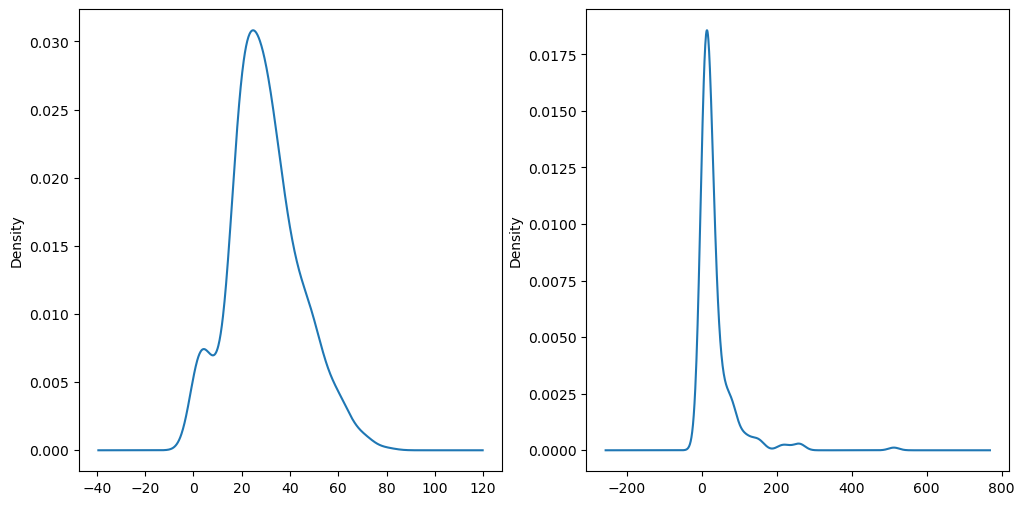

In [26]:
fig , ax = plt.subplots(1,2,figsize=(12,6))
df['age'].plot(kind='kde',ax=ax[0])
df['fare'].plot(kind='kde',ax=ax[1])

In [27]:
print(df['age'].skew())
print(df['fare'].skew())

0.38888061787537076
4.667008753630038


In [30]:
num_cols=['age','sibsp','parch']
ord_cols=['pclass']
cat_cols=['sex','embarked']
fare_cols=['fare']

In [39]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer()),
    ('scalar',StandardScaler())
])

In [48]:
ord_pipeline=Pipeline([
    ('ordinal',OrdinalEncoder(categories=[[1,2,3]]))
])

In [49]:
cat_pipeline=Pipeline([
    ('categorical',OneHotEncoder(sparse_output=False,drop='first',dtype=int))
])

In [50]:
fare_pipeline=Pipeline([
    ('imputer',SimpleImputer()),
    ('power',PowerTransformer()),
    ('scalar',StandardScaler())
])

In [52]:
transformer=ColumnTransformer(
    transformers=[
        ('tnf1',num_pipeline,num_cols),
        ('tnf2',fare_pipeline,fare_cols),
        ('tnf3',ord_pipeline,ord_cols),
        ('tnf4',cat_pipeline,cat_cols)
    ]
)

In [53]:
pipe=Pipeline([
    ('preprocessing',transformer),
    ('model',LogisticRegression())
])

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [55]:
pipe.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...), ('tnf2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
pred=pipe.predict(x_test)

In [57]:
acc=accuracy_score(y_test,pred)

In [58]:
acc

0.8089887640449438